import of required libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

Records of given dataset

In [5]:
data=pd.read_csv('data.csv',encoding = "ISO-8859-1",sep=',')
data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


**Information of the columns in a data**

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


**Description of numeric features**

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


**Description of non numeric features**

In [8]:
data.describe(exclude=['int64', 'float64']).T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,10/31/2011 14:41,1114
Country,541909,38,United Kingdom,495478


**Check for null values**

In [9]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

**Shape of the available data**

In [10]:
data.shape

(541909, 8)

**Delete all the missing records**

In [11]:
data.dropna(inplace=True)
print('data Shape:', data.shape)
data.isnull().sum()

data Shape: (406829, 8)


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

**Checking of whether negative values present in Quantity and Unit Price**

In [12]:
data[data['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


**Drop the negative values or quantity**

In [13]:
data.drop(data[data['Quantity']<0].index, inplace=True)
print('data Shape after dropping negative quantities:', data.shape)

data Shape after dropping negative quantities: (397924, 8)


**Calculation of total amount or monetary value**

In [14]:
data['sales_amount']=data['Quantity']*data['UnitPrice']
new_data=data.groupby('CustomerID')['sales_amount'].sum().reset_index()
new_data.head()

,CustomerID,sales_amount
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


**Calculating the number of transactions of each customer**

In [15]:
num_transactions=data.groupby('CustomerID')['InvoiceNo'].count().reset_index()
num_transactions.head()

,CustomerID,InvoiceNo
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


**Calculate Last Transaction**

In [16]:
data['InvoiceDate']=pd.to_datetime(data['InvoiceDate'])
data['last_transaction']=(data['InvoiceDate'].max()-data['InvoiceDate']).dt.days
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,sales_amount,last_transaction
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373


In [17]:
lt=data.groupby(['CustomerID','Country'])['last_transaction'].max().reset_index()
lt.head()

,CustomerID,Country,last_transaction
0,12346.0,United Kingdom,325
1,12347.0,Iceland,366
2,12348.0,Finland,357
3,12349.0,Italy,18
4,12350.0,Norway,309


Merging of data

In [18]:
merge_table=pd.merge(lt,num_transactions,how='inner',on='CustomerID')
new_df=pd.merge(merge_table,new_data,how='inner',on='CustomerID')
new_df


,CustomerID,Country,last_transaction,InvoiceNo,sales_amount
0,12346.0,United Kingdom,325,1,77183.60
1,12347.0,Iceland,366,182,4310.00
2,12348.0,Finland,357,31,1797.24
3,12349.0,Italy,18,73,1757.55
4,12350.0,Norway,309,17,334.40
...,...,...,...,...,...
4342,18280.0,United Kingdom,277,10,180.60
4343,18281.0,United Kingdom,180,7,80.82
4344,18282.0,United Kingdom,125,12,178.05
4345,18283.0,United Kingdom,336,756,2094.88


**Removal of Outliers using boxplot**

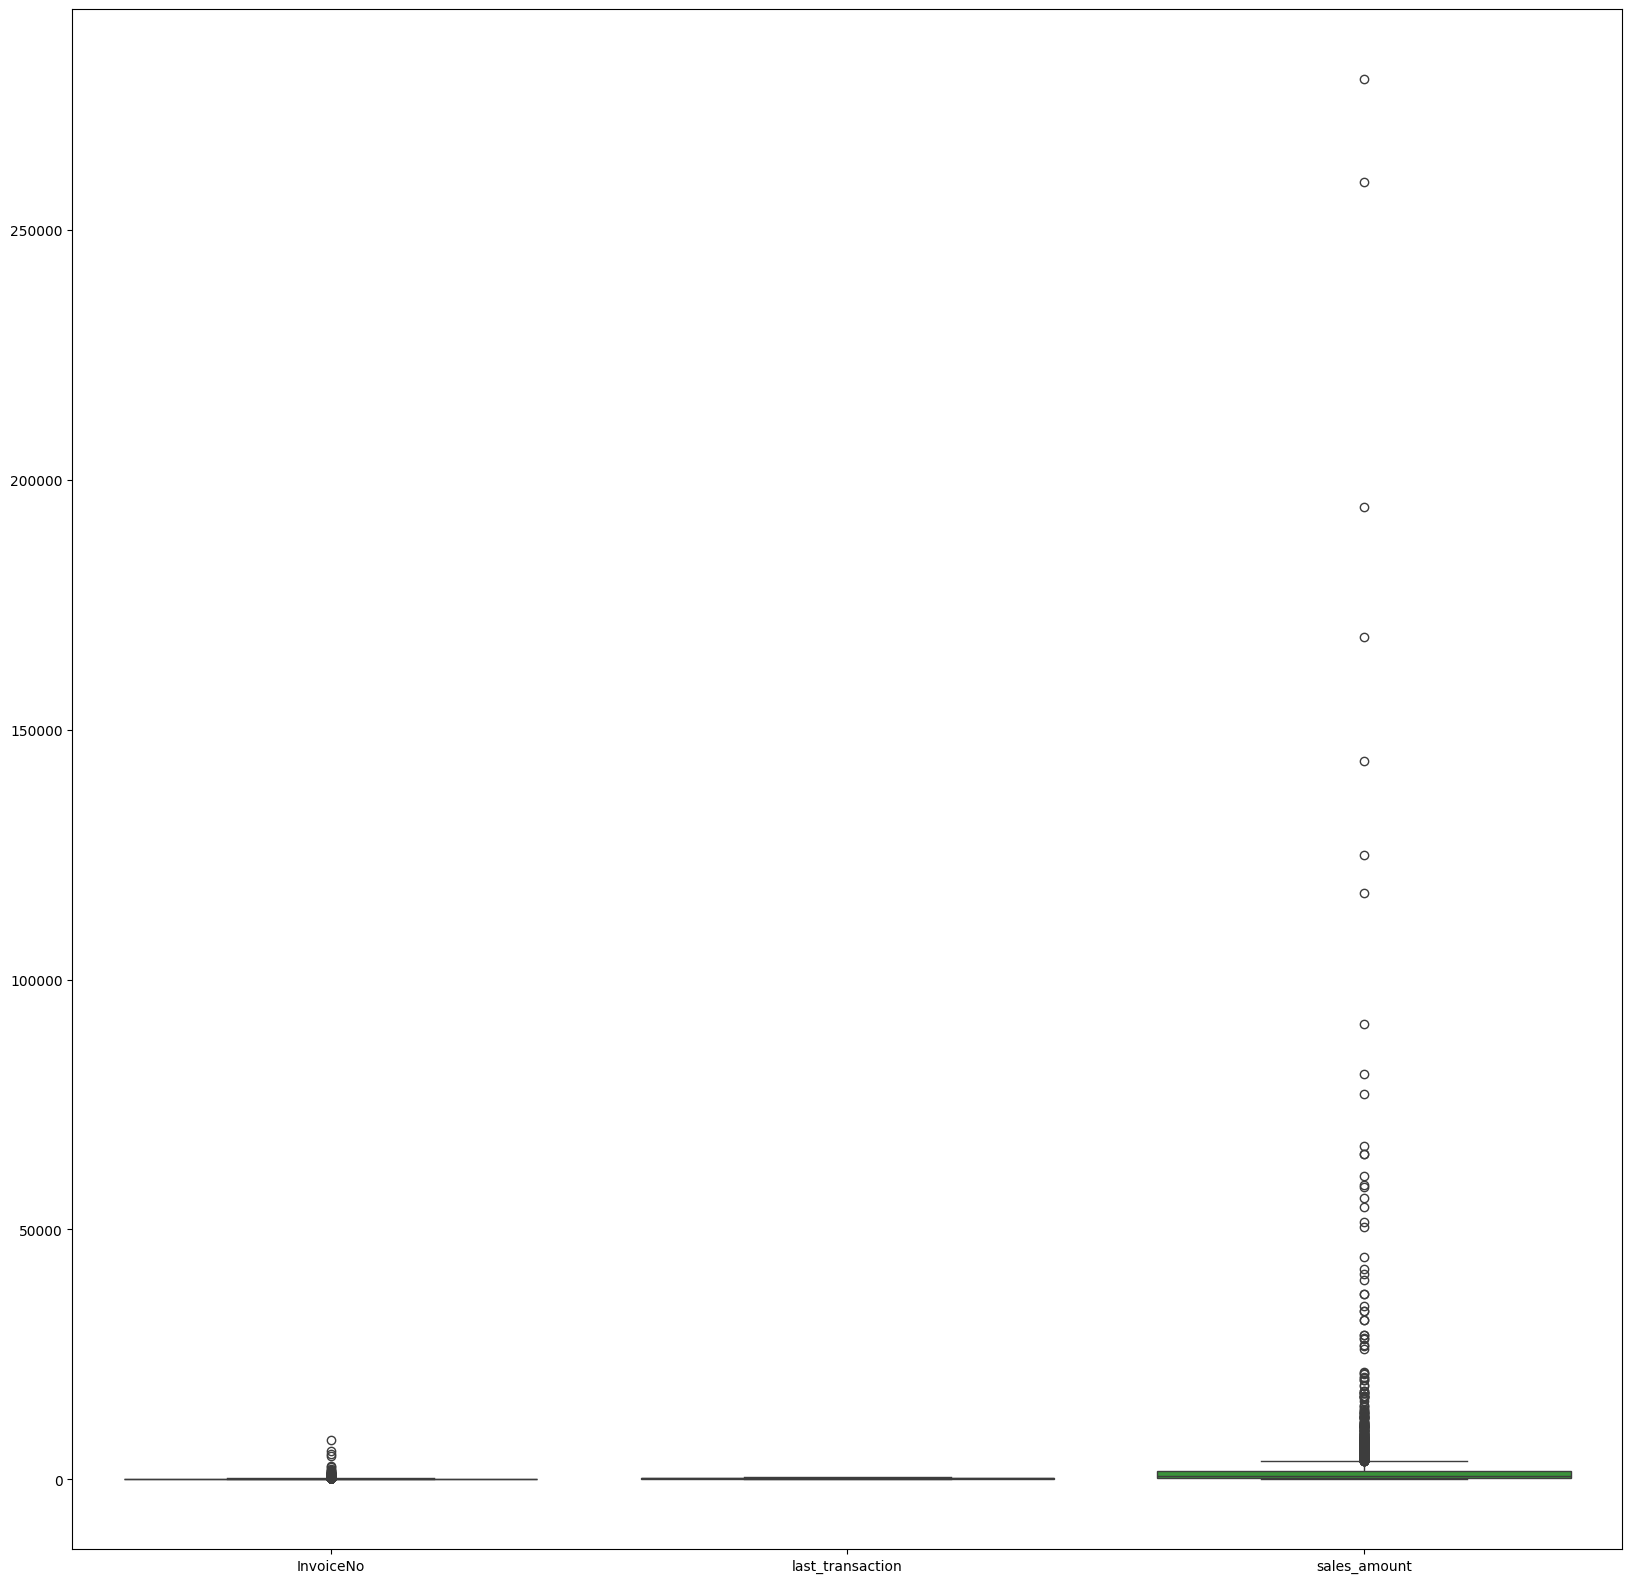

In [19]:
plt.figure(figsize=(20,20))
sns.boxplot(data = new_df[['InvoiceNo', 'last_transaction', 'sales_amount']])
plt.show()

lower limit: -1738.32
upper limit: 3717.12
shape: (3923, 5)


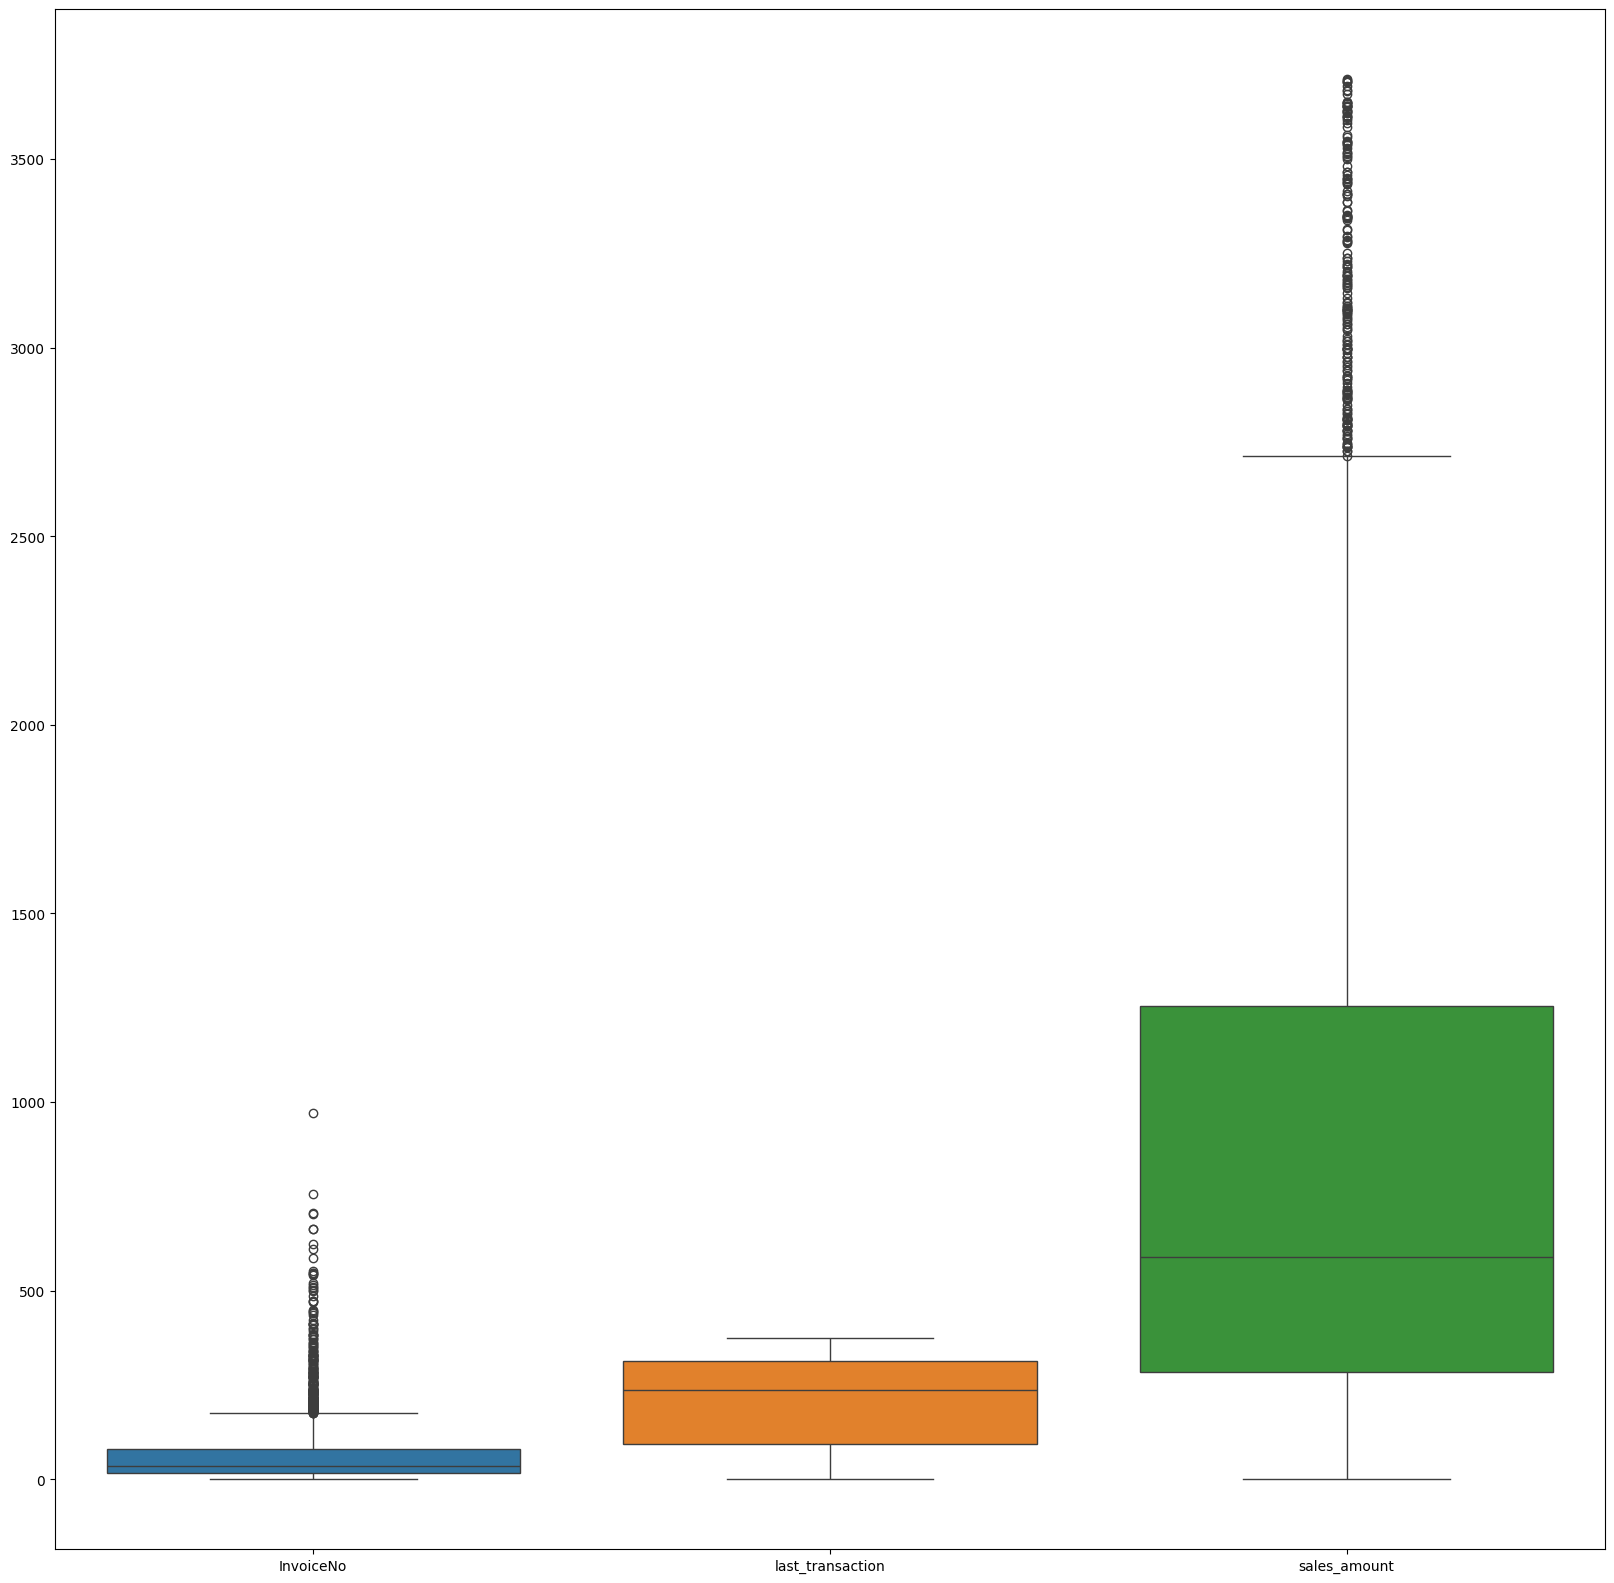

In [20]:
IQR=new_df['sales_amount'].quantile(0.75)-new_df['sales_amount'].quantile(0.25)
lower_limit=new_df['sales_amount'].quantile(0.25)-(1.5*IQR)
upper_limit=new_df['sales_amount'].quantile(0.75)+(1.5*IQR)
print('lower limit:', lower_limit)
print('upper limit:', upper_limit)
new_df_iqr=new_df[(new_df['sales_amount']>=lower_limit) & (new_df['sales_amount']<=upper_limit)]
print('shape:', new_df_iqr.shape)
plt.figure(figsize=(20,20))
sns.boxplot(data = new_df_iqr[['InvoiceNo', 'last_transaction', 'sales_amount']])
plt.show()

In [21]:
new_df_iqr.reset_index(drop=True, inplace=True)
new_df_iqr.head()

,CustomerID,Country,last_transaction,InvoiceNo,sales_amount
0,12348.0,Finland,357,31,1797.24
1,12349.0,Italy,18,73,1757.55
2,12350.0,Norway,309,17,334.40
3,12352.0,Norway,296,85,2506.04
4,12353.0,Bahrain,203,4,89.00


**Visualization of correlation matrix using heatmap**

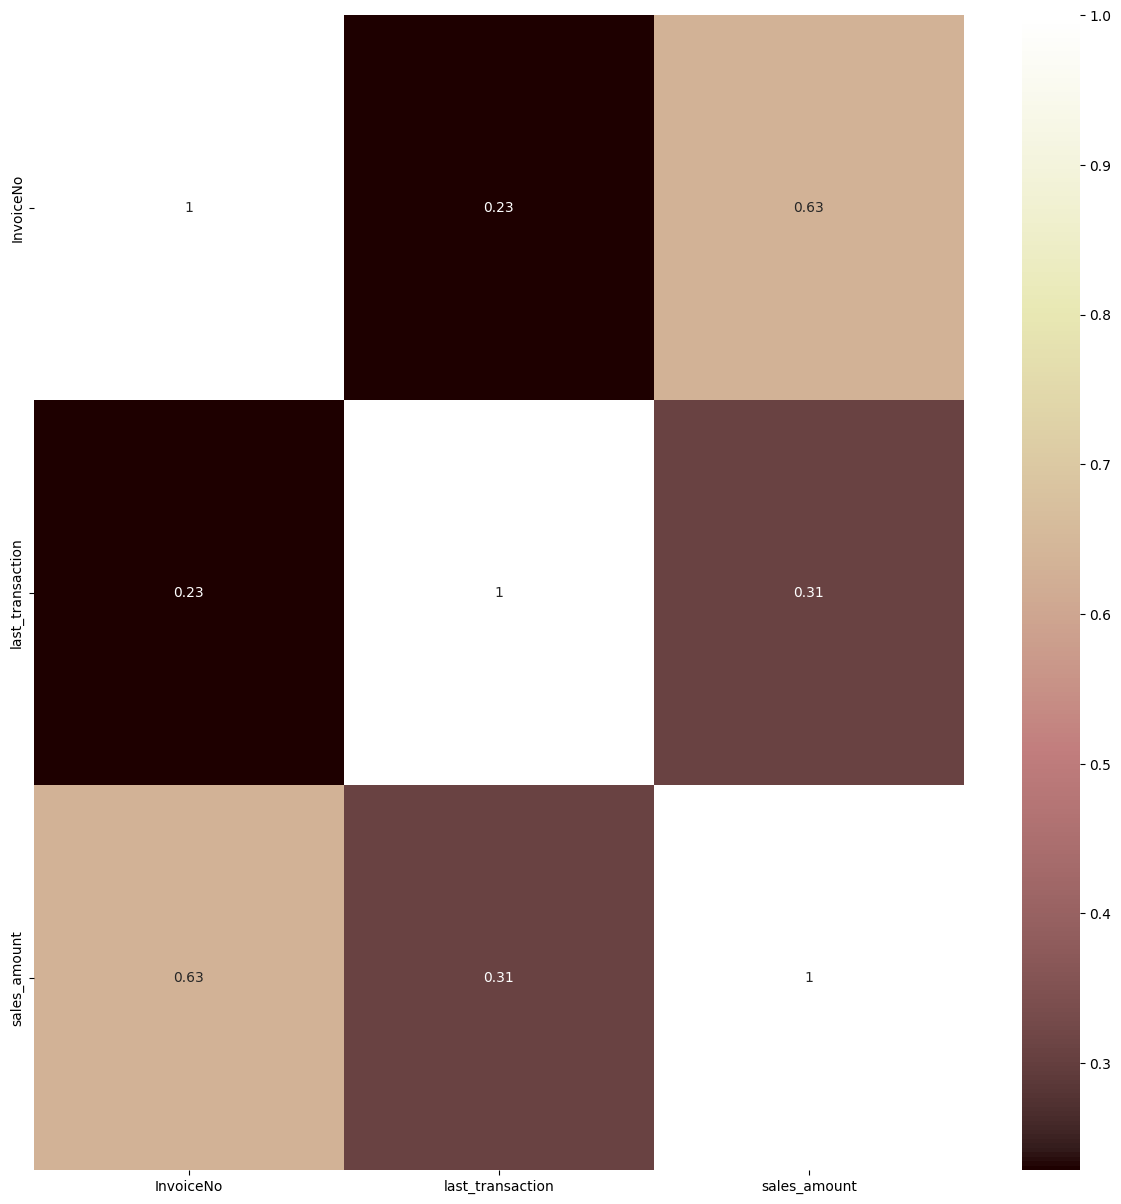

In [22]:
data=new_df_iqr[['InvoiceNo', 'last_transaction', 'sales_amount']]
plt.figure(figsize=(15,15))
sns.heatmap(data.corr(),cmap="pink", annot=True)
plt.show()

**Normalization of given dataset using MinMaxScaler**

In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data_scaled=scaler.fit_transform(data)
data_scaled=pd.DataFrame(data_scaled, columns=data.columns)
#data_scaled['Country']=new_df_iqr['Country']
data_scaled.head()

,InvoiceNo,last_transaction,sales_amount
0,0.030960,0.957105,0.484200
1,0.074303,0.048257,0.473507
2,0.016512,0.828418,0.090092
3,0.086687,0.793566,0.675160
4,0.003096,0.544236,0.023978


**K Means Clustering - Plot the graph using elbow method**

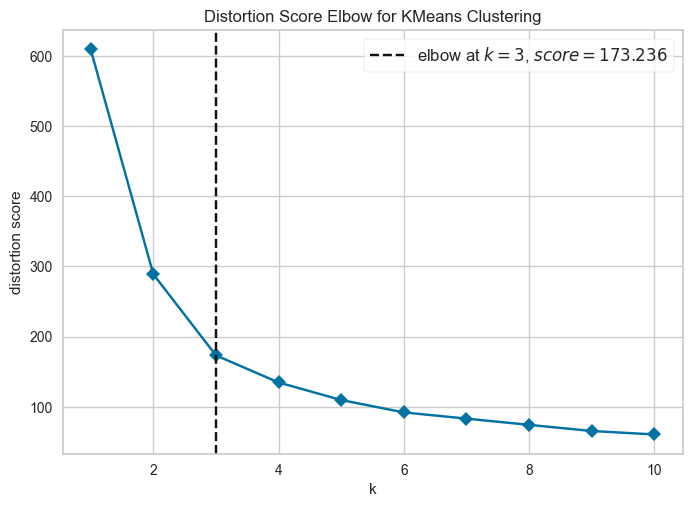

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [26]:
# Elbow Method for K means
# Import ElbowVisualizer
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(1,11), timings=False)
visualizer.fit(data_scaled)        # Fit data to visualizer
visualizer.show()        # Finalize and render figure

In [29]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(data_scaled)
data_scaled['clusters']= y_predicted
data_scaled

,InvoiceNo,last_transaction,sales_amount,clusters
0,0.030960,0.957105,0.484200,0
1,0.074303,0.048257,0.473507,2
2,0.016512,0.828418,0.090092,1
3,0.086687,0.793566,0.675160,0
4,0.003096,0.544236,0.023978,1
...,...,...,...,...
3918,0.009288,0.742627,0.048656,1
3919,0.006192,0.482574,0.021774,2
3920,0.011352,0.335121,0.047969,2
3921,0.779154,0.900804,0.564388,0


In [28]:
km.cluster_centers_

array([[0.04274922, 0.77443512, 0.15747944],
       [0.0400966 , 0.21854884, 0.1487773 ],
       [0.15828573, 0.79866329, 0.63390963]])

**Model Evaluation**

In [30]:
from sklearn.metrics import silhouette_samples, silhouette_score
score = silhouette_score(data_scaled, km.labels_, metric='euclidean')
print(score)

0.7738291094746175
